# Hierarchical Clustering 

In this notebook we will see **how hierarchical (agglomerative) clustering works** on a small, easy-to-visualise dataset.

## The idea in 4 lines

1. Start with **every point as its own cluster**.
2. Find the **two closest clusters** and merge them.
3. Repeat step 2 until only **one big cluster** is left.
4. Draw the merges as a tree → that tree is called a **dendrogram**.

We then **cut the dendrogram horizontally** at some height to decide our final **K** (number of clusters).


## Tools we will use

| Step | Library | Why |
|---|---|---|
| Draw the dendrogram | **scipy** | sklearn has no built-in dendrogram |
| Do the actual clustering | **sklearn — `AgglomerativeClustering`** | the standard ML library |


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scipy — only for the dendrogram picture
from scipy.cluster.hierarchy import linkage, dendrogram

# sklearn — the actual clustering algorithm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

## 2. Load the data


In [2]:
df = pd.read_csv('iris_sample.csv')
print('Shape:', df.shape)
df

Shape: (21, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,4.3,3.0,1.1,0.1,setosa
1,5.1,3.4,1.5,0.2,setosa
2,4.8,3.1,1.6,0.2,setosa
3,4.8,3.0,1.4,0.3,setosa
4,5.1,3.5,1.4,0.3,setosa
5,5.3,3.7,1.5,0.2,setosa
6,5.0,3.4,1.6,0.4,setosa
7,6.1,2.9,4.7,1.4,versicolor
8,5.5,2.5,4.0,1.3,versicolor
9,5.5,2.4,3.8,1.1,versicolor


## 3. Pick features and scale them

We use only **petal_length** and **petal_width** so we can plot everything in 2D.

> **Note:** clustering is **unsupervised**, so we drop the `species` column before clustering. We will only use `species` at the end to *check* how well clustering matched reality.

Hierarchical clustering uses **distance**, so features must be on the **same scale**. We use `StandardScaler` (mean 0, std 1).

In [3]:
X = df[['petal_length', 'petal_width']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Original first 3 rows:\n', X[:3])
print('\nScaled first 3 rows:\n', X_scaled[:3].round(2))

Original first 3 rows:
 [[1.1 0.1]
 [1.5 0.2]
 [1.6 0.2]]

Scaled first 3 rows:
 [[-1.47 -1.41]
 [-1.24 -1.28]
 [-1.19 -1.28]]


## 4. Look at the raw data first

Each point is labelled with its **row index** so we can spot it again in the dendrogram.

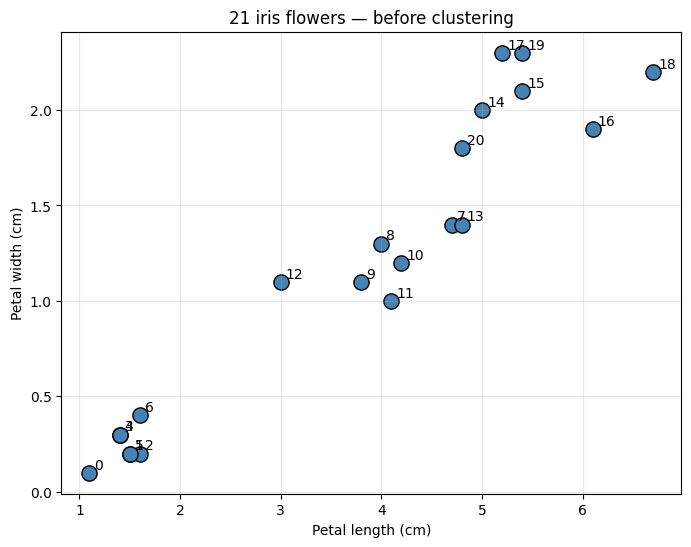

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=120, c='steelblue', edgecolor='black')

for i in range(len(X)):
    plt.text(X[i, 0] + 0.05, X[i, 1] + 0.02, str(i), fontsize=10)

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('21 iris flowers — before clustering')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Draw the dendrogram to decide K

We use **scipy** here *only* to **see** the merge tree. We are not using it to make clusters — that job is given to sklearn in the next step.

**How to read the dendrogram:**

- The **x-axis** shows the points (or groups of points).
- The **y-axis** is the distance at which two clusters were merged.
- A **short bar** = merged early = points are very similar.
- A **tall bar** = merged late = clusters were far apart.

**Rule of thumb to pick K:** find the **tallest vertical gap** that no horizontal merge crosses, and draw a horizontal line through it. The number of vertical lines it crosses = **K**.

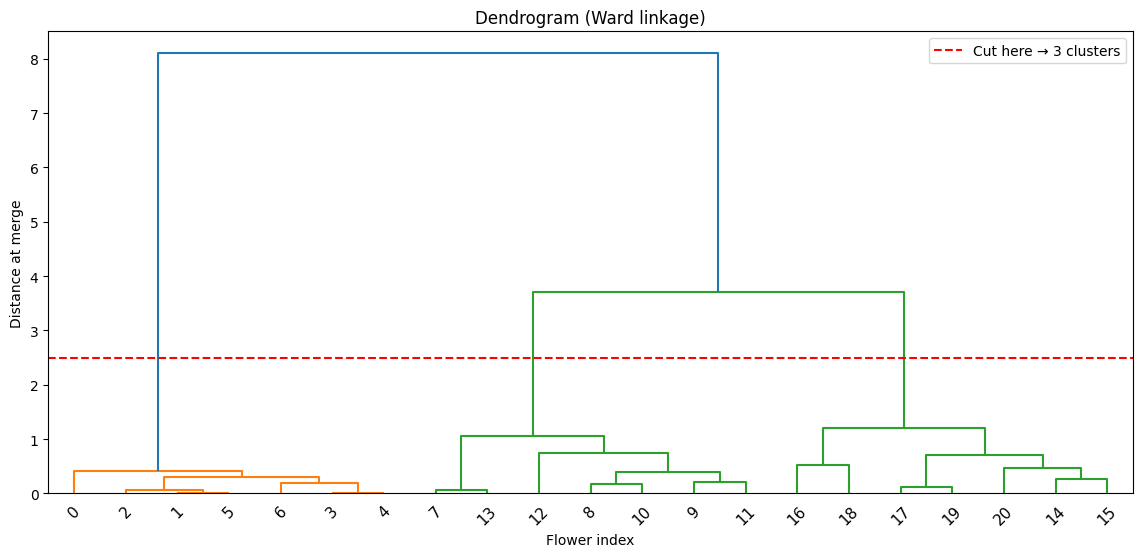

From the dendrogram we decide K = 3


In [ ]:
# linkage() runs the whole agglomerative algorithm and returns a merge matrix
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=[str(i) for i in range(len(X_scaled))],
    leaf_font_size=11,
)
plt.axhline(y=2.5, color='red', linestyle='--', label='Cut here → 3 clusters')
plt.title('Dendrogram (Ward linkage)')
plt.xlabel('Flower index')
plt.ylabel('Distance at merge')
plt.legend()
plt.show()

print('From the dendrogram we decide K = 3')

## 6. Fit Hierarchical Clustering with **sklearn**

Now that we know **K = 3** from the dendrogram, we use sklearn's `AgglomerativeClustering` to actually group the points.

Important parameters:

- `n_clusters=3` — how many clusters we want (we picked this from the dendrogram).
- `linkage='ward'` — same linkage method we used in the dendrogram, so results match.
- `metric='euclidean'` — distance metric (ward only works with euclidean).

`fit_predict` does two things at once: trains the model **and** returns the cluster label for every point.

In [6]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')
labels = hc.fit_predict(X_scaled)

print('Cluster label for each of the 21 flowers:')
print(labels)

Cluster label for each of the 21 flowers:
[1 1 1 1 1 1 1 2 2 2 2 2 2 2 0 0 0 0 0 0 0]


## 7. Attach the labels back to the dataframe

In [7]:
df['cluster'] = labels
df

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,4.3,3.0,1.1,0.1,setosa,1
1,5.1,3.4,1.5,0.2,setosa,1
2,4.8,3.1,1.6,0.2,setosa,1
3,4.8,3.0,1.4,0.3,setosa,1
4,5.1,3.5,1.4,0.3,setosa,1
5,5.3,3.7,1.5,0.2,setosa,1
6,5.0,3.4,1.6,0.4,setosa,1
7,6.1,2.9,4.7,1.4,versicolor,2
8,5.5,2.5,4.0,1.3,versicolor,2
9,5.5,2.4,3.8,1.1,versicolor,2


## 8. Plot the final clusters

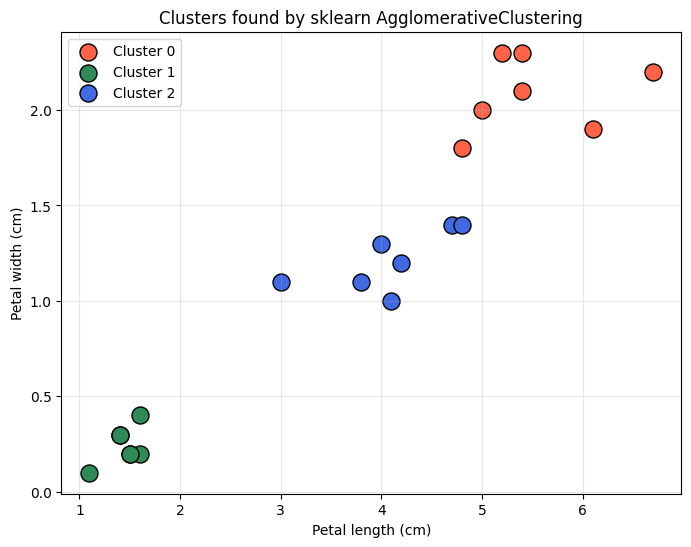

In [8]:
plt.figure(figsize=(8, 6))
colors = ['tomato', 'seagreen', 'royalblue']

for c in np.unique(labels):
    mask = labels == c
    plt.scatter(X[mask, 0], X[mask, 1],
                s=150, c=colors[c], edgecolor='black',
                label=f'Cluster {c}')

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Clusters found by sklearn AgglomerativeClustering')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Did clustering match the real species?

Since the CSV already has true species labels, we can peek at how well our **unsupervised** clusters line up with reality. Each row should ideally have all 7 flowers in a single column.

In [11]:
pd.crosstab(df['species'], df['cluster'],
            rownames=['true species'], colnames=['cluster'])

cluster,0,1,2
true species,,,
setosa,0,7,0
versicolor,0,0,7
virginica,7,0,0


## Recap

1. **Load** the clean CSV with `pd.read_csv`.
2. **Scale** the features with `StandardScaler` (distance-based algorithm).
3. Draw the **dendrogram** with `scipy.cluster.hierarchy` and pick **K** by eye.
4. Fit **`sklearn.cluster.AgglomerativeClustering(n_clusters=K, linkage='ward')`**.
5. Call `.fit_predict(X_scaled)` to get the cluster label for every point.
6. **Visualise** and validate.

### Try this yourself

- Change `linkage='ward'` to `'single'`, `'complete'` or `'average'` (in **both** the dendrogram and the sklearn model) and see how the clusters change.
- Use all 4 features instead of just 2 — does clustering get better?